In [509]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

In [510]:
root_path = "/home/stefan/ioai-prep/kits/ojia-2026/nurse"

seed = 42

# Subtask 1

In [511]:
df_train = pd.read_csv(f"{root_path}/train_data.csv")
df_test = pd.read_csv(f"{root_path}/test_data.csv")

In [512]:
subtask1 = [df_train["day_28_flg"].isna().sum()]
subtask1

[1235]

In [513]:
f"{subtask1[0] / len(df_train) * 100:.2f}% missing"

'92.51% missing'

# Subtask 2

In [514]:
labeled_df = df_train.dropna(subset=["day_28_flg"])

sofa_gt10_mask = labeled_df["sofa_first"] > 10
sofa_le10_mask = labeled_df["sofa_first"] <= 10

mortality_gt10 = labeled_df[sofa_gt10_mask]["day_28_flg"].mean() * 100
mortality_le10 = labeled_df[sofa_le10_mask]["day_28_flg"].mean() * 100

In [515]:
subtask2 = [mortality_gt10, mortality_le10]
subtask2

[0.0, 51.02040816326531]

# Subtask 3

## Data

In [516]:
unlabeled_mask = df_train["day_28_flg"].isna()

df_train_labeled = df_train[~unlabeled_mask]
df_train_unlabeled = df_train[unlabeled_mask]

In [517]:
X_train_labeled = df_train_labeled.drop("day_28_flg", axis=1)
y_train_labeled = df_train_labeled["day_28_flg"]

X_train_unlabeled = df_train_unlabeled.drop("day_28_flg", axis=1)
y_train_unlabeled = df_train_unlabeled["day_28_flg"]

In [518]:
cols_with_nans = X_train_labeled.columns[X_train_labeled.isna().any()].tolist()

X_train_labeled = X_train_labeled.drop(columns=cols_with_nans)
X_train_unlabeled = X_train_unlabeled.drop(columns=cols_with_nans)
df_test = df_test.drop(columns=cols_with_nans)

cols_with_nans

['weight_first', 'bmi', 'po2_first', 'pco2_first', 'iv_day_1']

In [519]:
cat_cols = X_train_labeled.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X_train_labeled.columns if c not in cat_cols]

cat_cols

['service_unit', 'day_icu_intime']

In [520]:
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols),
    ],
    remainder="drop",
)

In [521]:
X_train_labeled = preprocessor.fit_transform(X_train_labeled)
X_train_unlabeled = preprocessor.transform(X_train_unlabeled)
test_feats = preprocessor.transform(df_test)

In [522]:
X_train, X_test, y_train, y_test = train_test_split(X_train_labeled, y_train_labeled, test_size=0.2, random_state=seed)

## Model

In [523]:
def evaluate(clf):
    cv = cross_val_score(clf, X_train, y_train, cv=3, scoring="roc_auc")
    cv = cv.mean() - cv.std()

    clf.fit(X_train, y_train)
    preds = clf.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, preds), cv

In [524]:
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=seed)

evaluate(rf)

(0.828125, 0.6779374360993333)

In [525]:
y_train_unlabeled = rf.predict(X_train_unlabeled)
X_train = np.concatenate([X_train_labeled, X_train_unlabeled])
y_train = np.concatenate([y_train_labeled, y_train_unlabeled])

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=seed)

In [526]:
lr = LogisticRegression(max_iter=3000, class_weight="balanced", C=0.1, random_state=seed)

evaluate(lr)

(0.9710864485981308, 0.9589741702415018)

## Predictions

In [527]:
subtask3 = lr.predict_proba(test_feats)[:, 1]

<Axes: ylabel='Count'>

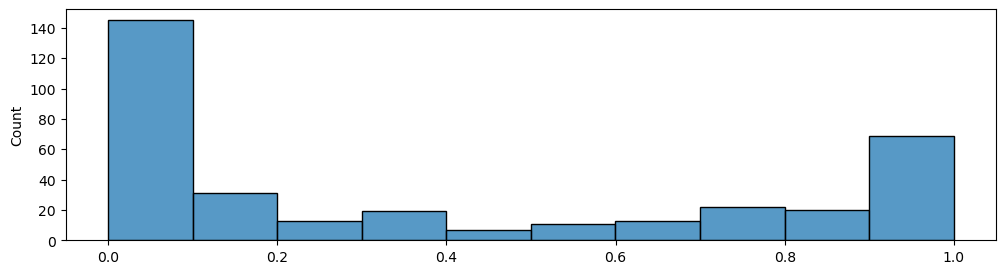

In [528]:
plt.figure(figsize=(12,3))
sns.histplot(subtask3)

# Submission

In [529]:
def build_submission(sid, ans):
    id_ = df_test["ID"] if sid == 3 else 1
    if sid == 2:
        id_ = [1, 2]
    return pd.DataFrame({"datapointID": id_, "subtaskID": sid, "answer": ans})

In [530]:
subtasks = [
    (1, subtask1),
    (2, subtask2),
    (3, subtask3)
]

sub = pd.concat([build_submission(sid, ans) for sid, ans in subtasks])

In [531]:
sub.head()

,datapointID,subtaskID,answer
0,1,1,1235.000000
0,1,2,0.000000
1,2,2,51.020408
0,0,3,0.025565
1,1,3,0.976737


In [532]:
sub.to_csv(f"{root_path}/submission.csv", index=False)